# Exploration et Nettoyage des Données

Ce notebook présente les premières étapes du projet :
- Chargement du dataset immobilier (communesdvf2024.csv)
- Exploration des données
- Nettoyage et préparation pour l'analyse

In [29]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [30]:
# Import des fonctions utilitaires du dossier scripts
import sys
sys.path.append('../scripts')
from data_utils import load_main_dataset, load_communes, enrich_with_commune_name, clean_data

In [31]:
# Chargement du dataset
# df = pd.read_csv('../data/communesdvf2024.csv')
df = load_main_dataset('../data/communesdvf2024.csv')
df.head()

,INSEE_COM,annee,nb_mutations,NbMaisons,NbApparts,PropMaison,PropAppart,PrixMoyen,Prixm2Moyen,SurfaceMoy
0,01001,2024,4,4.0,0.0,0.0,100.0,290575,3258,96
1,01002,2024,2,2.0,0.0,0.0,100.0,267500,1942,140
2,01004,2024,133,70.0,63.0,47.0,53.0,194332,2323,83
3,01005,2024,47,16.0,31.0,66.0,34.0,228481,2711,85
4,01007,2024,24,24.0,0.0,0.0,100.0,223065,2322,95


In [32]:
# Chargement du fichier de correspondance code INSEE ↔ nom commune
communes = load_communes('../data/communes.csv')

df = enrich_with_commune_name(df, communes)

# Vérification
print(df[['INSEE_COM', 'LIBGEO']].head())

  INSEE_COM                   LIBGEO
0     01001  L'Abergement-Clémenciat
1     01002    L'Abergement-de-Varey
2     01004        Ambérieu-en-Bugey
3     01005      Ambérieux-en-Dombes
4     01007                 Ambronay


## Ajout du nom des communes à partir du code INSEE

In [33]:
# Nettoyage du dataset
# df = df.drop_duplicates()
df = clean_data(df)

# Gestion des valeurs manquantes
print("Valeurs manquantes par colonne :\n", df.isnull().sum())
# Exemple : suppression des lignes avec valeurs manquantes critiques
# df = df.dropna(subset=["Prixm2Moyen", "annee"])

df = df[df['LIBGEO'].notnull()]

# Vérification des types de colonnes
df.info()

Valeurs manquantes par colonne :
 INSEE_COM        1
annee            0
nb_mutations     0
NbMaisons        1
NbApparts        1
PropMaison       1
PropAppart       1
PrixMoyen        0
Prixm2Moyen      0
SurfaceMoy       0
CODGEO          43
LIBGEO          43
dtype: int64
<class 'pandas.DataFrame'>
Index: 29789 entries, 0 to 29830
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   INSEE_COM     29789 non-null  str    
 1   annee         29789 non-null  int64  
 2   nb_mutations  29789 non-null  int64  
 3   NbMaisons     29789 non-null  float64
 4   NbApparts     29789 non-null  float64
 5   PropMaison    29789 non-null  float64
 6   PropAppart    29789 non-null  float64
 7   PrixMoyen     29789 non-null  int64  
 8   Prixm2Moyen   29789 non-null  int64  
 9   SurfaceMoy    29789 non-null  int64  
 10  CODGEO        29789 non-null  str    
 11  LIBGEO        29789 non-null  str    
dtypes: float64(4), int64(5), 

## Nettoyage des données

- Suppression des doublons
- Gestion des valeurs manquantes
- Vérification des types de colonnes

In [34]:
# Suppression des doublons
print(f"Nombre de doublons avant : {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Nombre de doublons après : {df.duplicated().sum()}")

# Gestion des valeurs manquantes
print("Valeurs manquantes par colonne :\n", df.isnull().sum())
# Exemple : suppression des lignes avec valeurs manquantes critiques
# df = df.dropna(subset=["prix_m2", "nom_commune", "annee"])

# Vérification des types de colonnes
df.info()

Nombre de doublons avant : 0
Nombre de doublons après : 0
Valeurs manquantes par colonne :
 INSEE_COM       0
annee           0
nb_mutations    0
NbMaisons       0
NbApparts       0
PropMaison      0
PropAppart      0
PrixMoyen       0
Prixm2Moyen     0
SurfaceMoy      0
CODGEO          0
LIBGEO          0
dtype: int64
<class 'pandas.DataFrame'>
Index: 29789 entries, 0 to 29830
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   INSEE_COM     29789 non-null  str    
 1   annee         29789 non-null  int64  
 2   nb_mutations  29789 non-null  int64  
 3   NbMaisons     29789 non-null  float64
 4   NbApparts     29789 non-null  float64
 5   PropMaison    29789 non-null  float64
 6   PropAppart    29789 non-null  float64
 7   PrixMoyen     29789 non-null  int64  
 8   Prixm2Moyen   29789 non-null  int64  
 9   SurfaceMoy    29789 non-null  int64  
 10  CODGEO        29789 non-null  str    
 11  LIBGEO        29789 no

## Calcul d'indicateurs clés

- Prix moyen au m² par année
- Top 10 des villes les plus chères

In [35]:
prix_par_ville = df.groupby("LIBGEO").filter(lambda x: x["nb_mutations"].sum() >= 5).groupby("LIBGEO")["Prixm2Moyen"].mean().sort_values(ascending=False)
print(prix_par_ville)
print(df[df["LIBGEO"] == "Espira-de-Conflent"][["Prixm2Moyen", "SurfaceMoy", "PrixMoyen", "nb_mutations"]])

LIBGEO
Val-d'Isère                11896.0
Saint-Jean-Cap-Ferrat      11420.0
Le Tholonet                10999.0
Saint-Tropez               10870.0
Courchevel                 10589.0
                            ...   
Cascastel-des-Corbières      552.0
Dommartin-le-Franc           548.0
Lacelle                      547.0
Saint-Sever-du-Moustier      529.0
Brézilhac                    482.0
Name: Prixm2Moyen, Length: 16472, dtype: float64
       Prixm2Moyen  SurfaceMoy  PrixMoyen  nb_mutations
22430        16279          43     700000             1


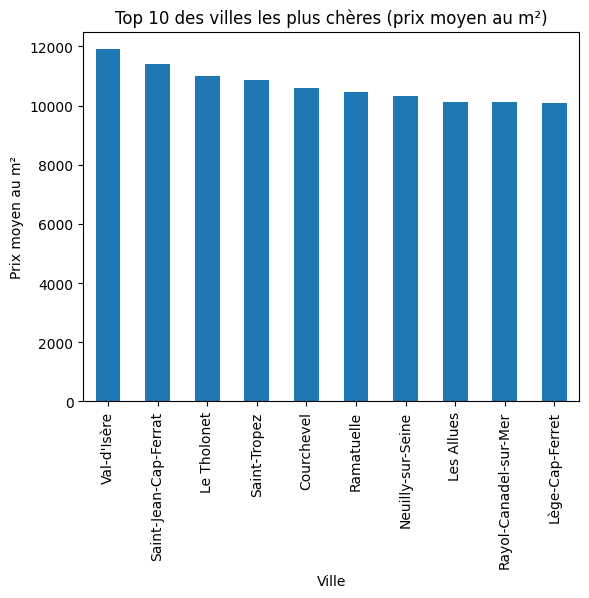

In [36]:
# Visualisation de l'évolution du prix moyen au m²
import matplotlib.pyplot as plt
top_villes = prix_par_ville.head(10)
top_villes.plot(kind="bar")
plt.title("Top 10 des villes les plus chères (prix moyen au m²)")
plt.xlabel("Ville")
plt.ylabel("Prix moyen au m²")
plt.show()


In [38]:
# Top 10 des villes les plus chères (au moins 5 transactions)
top_villes = (
    df.groupby("LIBGEO").filter(lambda x: x["nb_mutations"].sum() >= 5)
    .groupby("LIBGEO")["Prixm2Moyen"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
top_villes

LIBGEO
Val-d'Isère              11896.0
Saint-Jean-Cap-Ferrat    11420.0
Le Tholonet              10999.0
Saint-Tropez             10870.0
Courchevel               10589.0
Ramatuelle               10472.0
Neuilly-sur-Seine        10339.0
Les Allues               10129.0
Rayol-Canadel-sur-Mer    10106.0
Lège-Cap-Ferret          10071.0
Name: Prixm2Moyen, dtype: float64

## Dashboard Power BI

- Exporte le dataset nettoyé (df) au format CSV pour l'importer dans Power BI.
- Crée des KPI : prix moyen m², nombre de transactions, évolution prix.
- Graphiques recommandés :
    - Prix par ville
    - Evolution par année
    - Carte par département

In [39]:
# Export du dataset nettoyé pour Power BI
df.to_csv('../data/communesdvf2024_clean.csv', index=False)
print('Export terminé : ../data/communesdvf2024_clean.csv')

Export terminé : ../data/communesdvf2024_clean.csv
